## Week : 19

## Association Rule Mining

Association Rule Mining (ARM) in Machine Learning is a technique used to find hidden patterns and relationships between items in large datasets.

👉 ARM mhanto:
“Jar customer ne X ghetil, tar to Y pan gheil ka?”

Example:
Milk + Bread ghetnare lok mostly Butter pan ghetaat
➡️ Rule: {Milk, Bread} → {Butter}

### 🔹 Key Concepts

#### 1️⃣ Itemset:  
A group of items (e.g., {milk, bread})

👉 Items cha group  
Example: {Milk, Bread}

#### 2️⃣ Support:  
How frequently an itemset appears in the dataset

Formula:  
Support(X) = (Transactions containing X) / (Total transactions)

Kiti vela itemset dataset madhe disla    
X kiti frequently use jhala te

#### 3️⃣ Confidence:  
Probability that Y is bought when X is bought

Formula:  
Confidence(X → Y) = Support(X ∪ Y) / Support(X)

X asel tar Y yenayachi probability  
X zala ki Y honayachi chance

#### 4️⃣ Lift:  
Measures strength of rule (better than random or not)

Rule strong aahe ka random aahe te check karto

Formula:  
Lift = Confidence(X → Y) / Support(Y)

Lift > 1 → strong relation 👍  
Lift = 1 → no relation 😐  
Lift < 1 → weak relation 👎   

c:\Users\jadha\OneDrive\Desktop\gpp\Internship\env\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Frequent Itemsets:
    support                    itemsets
0     0.75           frozenset({Milk})
1     0.75          frozenset({Bread})
2     0.75         frozenset({Butter})
3     0.50    frozenset({Bread, Milk})
4     0.50   frozenset({Butter, Milk})
5     0.50  frozenset({Bread, Butter})

Association Rules:
            antecedents          consequents  support  confidence      lift
0   frozenset({Bread})    frozenset({Milk})      0.5    0.666667  0.888889
1    frozenset({Milk})   frozenset({Bread})      0.5    0.666667  0.888889
2  frozenset({Butter})    frozenset({Milk})      0.5    0.666667  0.888889
3    frozenset({Milk})  frozenset({Butter})      0.5    0.666667  0.888889
4   frozenset({Bread})  frozenset({Butter})      0.5    0.666667  0.888889
5  frozenset({Butter})   frozenset({Bread})      0.5    0.666667  0.888889


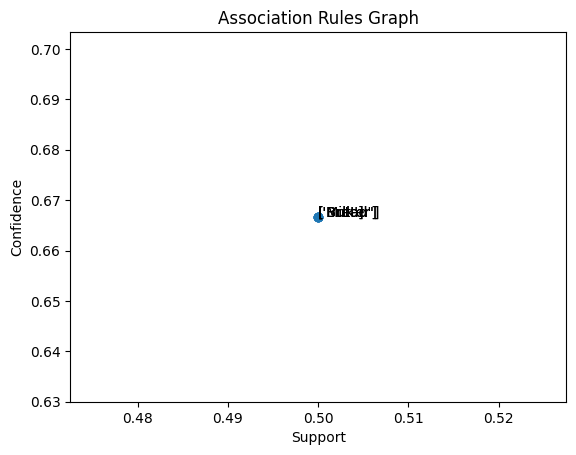

In [2]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt

# Simple dataset
data = {
    'Milk':   [1,1,0,1],
    'Bread':  [1,0,1,1],
    'Butter': [0,1,1,1]
}

df = pd.DataFrame(data)

# Step 1: Find frequent itemsets
frequent = apriori(df, min_support=0.5, use_colnames=True)

# Step 2: Generate rules
rules = association_rules(frequent, metric="confidence", min_threshold=0.6)

# Output
print("Frequent Itemsets:\n", frequent)
print("\nAssociation Rules:\n", rules[['antecedents','consequents','support','confidence','lift']])

# 🔹 Step 3: Simple Graph (Support vs Confidence)
plt.scatter(rules['support'], rules['confidence'])

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules Graph")

# Label each point
for i in range(len(rules)):
    plt.text(rules['support'].iloc[i],
             rules['confidence'].iloc[i],
             str(list(rules['antecedents'].iloc[i])))

plt.show()

#### Example:

Student Performance – Example 

👉 Scenario

Students cha behavior:

Study (regular study karto ka)  
Attendance (class la yeto ka)  
Assignment (assignments complete karto ka)

👉 Apan baghto ki he factors ekmekanshi related aahet ka?

Dataset:
    Study  Attendance  Assignment
0      1           1           1
1      1           0           1
2      0           1           0
3      1           1           1
4      1           1           0
5      0           1           1
6      1           0           1

Frequent Itemsets:
     support                             itemsets
0  0.714286                   frozenset({Study})
1  0.714286              frozenset({Attendance})
2  0.714286              frozenset({Assignment})
3  0.428571       frozenset({Study, Attendance})
4  0.571429       frozenset({Assignment, Study})
5  0.428571  frozenset({Assignment, Attendance})

Rules:
                antecedents              consequents   support  confidence  \
0       frozenset({Study})  frozenset({Attendance})  0.428571         0.6   
1  frozenset({Attendance})       frozenset({Study})  0.428571         0.6   
2  frozenset({Assignment})       frozenset({Study})  0.571429         0.8   
3       frozenset({Study})  frozenset({Assign

c:\Users\jadha\OneDrive\Desktop\gpp\Internship\env\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


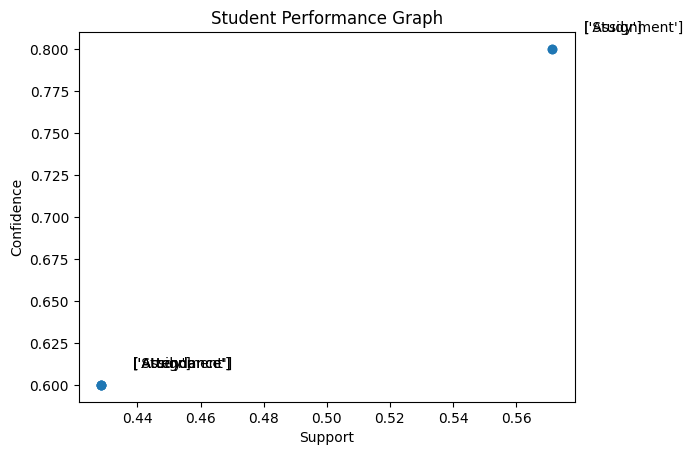

In [7]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt

# Step 1: Dataset (1 = Yes, 0 = No)
data = {
    'Study':      [1,1,0,1,1,0,1],
    'Attendance': [1,0,1,1,1,1,0],
    'Assignment': [1,1,0,1,0,1,1]
}

df = pd.DataFrame(data)

print("Dataset:\n", df)

# Step 2: Frequent Itemsets
frequent = apriori(df, min_support=0.4, use_colnames=True)

print("\nFrequent Itemsets:\n", frequent)

# Step 3: Association Rules
rules = association_rules(frequent, metric="confidence", min_threshold=0.6)

print("\nRules:\n", rules[['antecedents','consequents','support','confidence','lift']])

# Step 4: Graph
plt.scatter(rules['support'], rules['confidence'])

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Student Performance Graph")

# Label points
for i in range(len(rules)):
    plt.text(rules['support'].iloc[i] + 0.01,   # right shift
             rules['confidence'].iloc[i] + 0.01,  # up shift
             str(list(rules['antecedents'].iloc[i])))
plt.show()